In [44]:
import os
from pathlib import Path

current_dir = Path.cwd()
data_dir = None

check_dir = current_dir
while check_dir != check_dir.parent:  # Berhenti jika sudah mentok di root (misal C:\)
    if "satria-data-bdc" in check_dir.name.lower():
        data_dir = check_dir
        break
    check_dir = check_dir.parent

if data_dir is None:
    data_dir = current_dir

In [45]:
# Cell 2 (Print the directory structure in a tree-like format)
def print_tree(root_dir, max_files_per_folder=3, prefix=""):
    root_dir = Path(root_dir)
    entries = sorted(root_dir.iterdir(), key=lambda x: (x.is_file(), x.name))
    
    for i, entry in enumerate(entries):
        connector = "└── " if i == len(entries) - 1 else "├── "
        if entry.is_dir():
            n_files = len(list(entry.glob("*")))
            print(f"{prefix}{connector}{entry.name}/  ({n_files} item)")
            extension = "    " if i == len(entries) - 1 else "│   "
            print_tree(entry, max_files_per_folder, prefix + extension)
        else:
            print(f"{prefix}{connector}{entry.name}")

In [46]:
# Cell 3 (Summarize the structure of the dataset)
def summarize_structure(data_dir):
    data_dir = Path(data_dir)
    print(f"Struktur folder: {data_dir}\n")
    print(data_dir.name + "/")
    
    for split_dir in sorted(data_dir.iterdir()):
        if not split_dir.is_dir():
            continue
        print(f"├── {split_dir.name}/")
        subdirs = [d for d in split_dir.iterdir() if d.is_dir()]
        
        if subdirs:  # ada subfolder kelas (kemungkinan train)
            for cls_dir in sorted(subdirs):
                n_files = len(list(cls_dir.glob("*.*")))
                print(f"│   ├── {cls_dir.name}/  -> {n_files} file")
        else:  # tidak ada subfolder (kemungkinan test)
            files = list(split_dir.glob("*.*"))
            print(f"│   -> {len(files)} file (tanpa subfolder/label)")
            if files:
                print(f"│   -> contoh nama file: {[f.name for f in files[:5]]}")

In [47]:
# Execution
summarize_structure(data_dir)
print_tree(data_dir)

Struktur folder: c:\Users\HP\Documents\BDC 2026\satria-data-bdc-2026-1

satria-data-bdc-2026-1/
├── .git/
│   ├── hooks/  -> 14 file
│   ├── info/  -> 0 file
│   ├── logs/  -> 0 file
│   ├── objects/  -> 0 file
│   ├── refs/  -> 0 file
├── test/
│   -> 1458 file (tanpa subfolder/label)
│   -> contoh nama file: ['1.jpg', '10.jpg', '100.jpg', '1000.jpg', '1001.jpg']
├── train/
│   ├── 0_Recyclable/  -> 9999 file
│   ├── 1_Electronic/  -> 3961 file
│   ├── 2_Organic/  -> 12567 file
├── .git/  (13 item)
│   ├── hooks/  (14 item)
│   │   ├── applypatch-msg.sample
│   │   ├── commit-msg.sample
│   │   ├── fsmonitor-watchman.sample
│   │   ├── post-update.sample
│   │   ├── pre-applypatch.sample
│   │   ├── pre-commit.sample
│   │   ├── pre-merge-commit.sample
│   │   ├── pre-push.sample
│   │   ├── pre-rebase.sample
│   │   ├── pre-receive.sample
│   │   ├── prepare-commit-msg.sample
│   │   ├── push-to-checkout.sample
│   │   ├── sendemail-validate.sample
│   │   └── update.sample
│   ├── i

In [48]:
from PIL import Image

def find_corrupt_images(folder_path):
    """
    Scan semua file gambar di folder_path (termasuk subfolder),
    return dict berisi path file yang corrupt beserta pesan error-nya.
    """
    corrupt_files = {}
    all_files = list(Path(folder_path).rglob("*.*"))  # rglob = recursive, tangkap subfolder kelas juga
    
    for file_path in all_files:
        try:
            with Image.open(file_path) as img:
                img.verify()  # cek integritas struktur file
        except Exception as e:
            corrupt_files[str(file_path)] = str(e)
    
    return corrupt_files, len(all_files)

# --- Cek train ---
train_corrupt, train_total = find_corrupt_images(data_dir / "train")
print(f"[TRAIN] Total file discan: {train_total}")
print(f"[TRAIN] Jumlah file corrupt: {len(train_corrupt)}")
if train_corrupt:
    print("[TRAIN] Daftar file corrupt:")
    for path, err in train_corrupt.items():
        print(f"  - {path} -> {err}")

# --- Cek test ---
test_corrupt, test_total = find_corrupt_images(data_dir / "test")
print(f"\n[TEST] Total file discan: {test_total}")
print(f"[TEST] Jumlah file corrupt: {len(test_corrupt)}")
if test_corrupt:
    print("[TEST] Daftar file corrupt:")
    for path, err in test_corrupt.items():
        print(f"  - {path} -> {err}")

[TRAIN] Total file discan: 26527
[TRAIN] Jumlah file corrupt: 0

[TEST] Total file discan: 1458
[TEST] Jumlah file corrupt: 0


In [49]:
import hashlib

def compute_file_hash(file_path):
    """Hitung MD5 hash dari isi file (byte-level, exact match)."""
    hasher = hashlib.md5()
    with open(file_path, 'rb') as f:
        hasher.update(f.read())
    return hasher.hexdigest()

# --- Step 1: Hash semua file test, simpan sebagai lookup dict ---
test_hashes = {}  # {hash: file_path}
test_files = list((data_dir / "test").rglob("*.*"))

for file_path in test_files:
    file_hash = compute_file_hash(file_path)
    test_hashes[file_hash] = str(file_path)

print(f"Total unique hash di test: {len(test_hashes)} (dari {len(test_files)} file)")

# --- Step 2: Iterate train, cek tiap file apakah hash-nya match ke test ---
train_test_duplicates = {}  # {train_file_path: matching_test_file_path}
train_files = list((data_dir / "train").rglob("*.*"))

for file_path in train_files:
    file_hash = compute_file_hash(file_path)
    if file_hash in test_hashes:
        train_test_duplicates[str(file_path)] = test_hashes[file_hash]

print(f"\nJumlah file train yang identik (exact) dengan file test: {len(train_test_duplicates)}")
if train_test_duplicates:
    print("Daftar pasangan duplikat (train -> test):")
    for train_path, test_path in train_test_duplicates.items():
        print(f"  - {train_path}  <->  {test_path}")

Total unique hash di test: 1458 (dari 1458 file)

Jumlah file train yang identik (exact) dengan file test: 97
Daftar pasangan duplikat (train -> test):
  - c:\Users\HP\Documents\BDC 2026\satria-data-bdc-2026-1\train\1_Electronic\Player_105.jpg  <->  c:\Users\HP\Documents\BDC 2026\satria-data-bdc-2026-1\test\338.jpg
  - c:\Users\HP\Documents\BDC 2026\satria-data-bdc-2026-1\train\1_Electronic\Player_45.jpg  <->  c:\Users\HP\Documents\BDC 2026\satria-data-bdc-2026-1\test\979.jpg
  - c:\Users\HP\Documents\BDC 2026\satria-data-bdc-2026-1\train\2_Organic\O_4463.jpg  <->  c:\Users\HP\Documents\BDC 2026\satria-data-bdc-2026-1\test\271.jpg
  - c:\Users\HP\Documents\BDC 2026\satria-data-bdc-2026-1\train\2_Organic\O_4464.jpg  <->  c:\Users\HP\Documents\BDC 2026\satria-data-bdc-2026-1\test\598.jpg
  - c:\Users\HP\Documents\BDC 2026\satria-data-bdc-2026-1\train\2_Organic\O_4469.jpg  <->  c:\Users\HP\Documents\BDC 2026\satria-data-bdc-2026-1\test\467.jpg
  - c:\Users\HP\Documents\BDC 2026\satria-dat

In [50]:
import numpy as np
from PIL import Image
import random

random.seed(42)  # reproducibility

def sample_files_per_class(data_dir, class_folders, n_samples=500):
    """Ambil sample acak file per kelas folder train."""
    samples = {}
    for cls in class_folders:
        files = list((data_dir / "train" / cls).rglob("*.*"))
        n = min(n_samples, len(files))
        samples[cls] = random.sample(files, n)
        print(f"{cls}: sampling {n} dari {len(files)} file")
    return samples

# Sesuaikan nama subfolder dengan struktur aktual kamu
class_folders = ["0_Recyclable", "1_Electronic", "2_Organic"]  # GANTI sesuai nama folder asli
sampled_files = sample_files_per_class(data_dir, class_folders, n_samples=500)

# --- Analisis mode, dan warna/brightness per kelas ---
results = []
corrupt_files = []

for cls, files in sampled_files.items():
    for f in files:
        try:
            img = Image.open(f)
            img.verify()  # cek apakah file valid/corrupt
            img = Image.open(f)  # reopen setelah verify (verify() menutup file handle)
            mode = img.mode

            img_rgb = img.convert("RGB")  # paksa RGB biar histogram konsisten
            arr = np.array(img_rgb)

            mean_r, mean_g, mean_b = arr[:,:,0].mean(), arr[:,:,1].mean(), arr[:,:,2].mean()
            brightness = arr.mean()  # rata-rata semua channel = proxy brightness

            results.append({
                "class": cls,
                "file": str(f),
                "mode": mode,
                "mean_r": mean_r,
                "mean_g": mean_g,
                "mean_b": mean_b,
                "brightness": brightness
            })
        except Exception as e:
            corrupt_files.append((str(f), str(e)))

print(f"\nTotal file berhasil diproses: {len(results)}")
print(f"Total file corrupt/gagal dibuka: {len(corrupt_files)}")
if corrupt_files:
    print("Contoh file bermasalah:")
    for fp, err in corrupt_files[:10]:
        print(f"  - {fp}: {err}")

# --- Ringkasan mode gambar per kelas ---
import pandas as pd
df_results = pd.DataFrame(results)
print("\nDistribusi mode gambar per kelas:")
print(df_results.groupby("class")["mode"].value_counts())

# --- Ringkasan statistik warna & brightness per kelas ---
print("\nRata-rata channel warna & brightness per kelas:")
print(df_results.groupby("class")[["mean_r", "mean_g", "mean_b", "brightness"]].agg(["mean", "std"]))

0_Recyclable: sampling 500 dari 9999 file
1_Electronic: sampling 500 dari 3961 file
2_Organic: sampling 500 dari 12567 file

Total file berhasil diproses: 1500
Total file corrupt/gagal dibuka: 0

Distribusi mode gambar per kelas:
class         mode
0_Recyclable  RGB     487
              P        13
1_Electronic  RGB     497
              RGBA      2
              P         1
2_Organic     RGB     497
              P         3
Name: count, dtype: int64

Rata-rata channel warna & brightness per kelas:
                  mean_r                 mean_g                 mean_b  \
                    mean        std        mean        std        mean   
class                                                                    
0_Recyclable  187.221521  49.540268  181.610683  49.710720  176.455437   
1_Electronic  144.822147  46.688144  142.951888  46.388223  139.267478   
2_Organic     167.013816  47.401025  149.931305  46.761231  118.201981   

                         brightness             


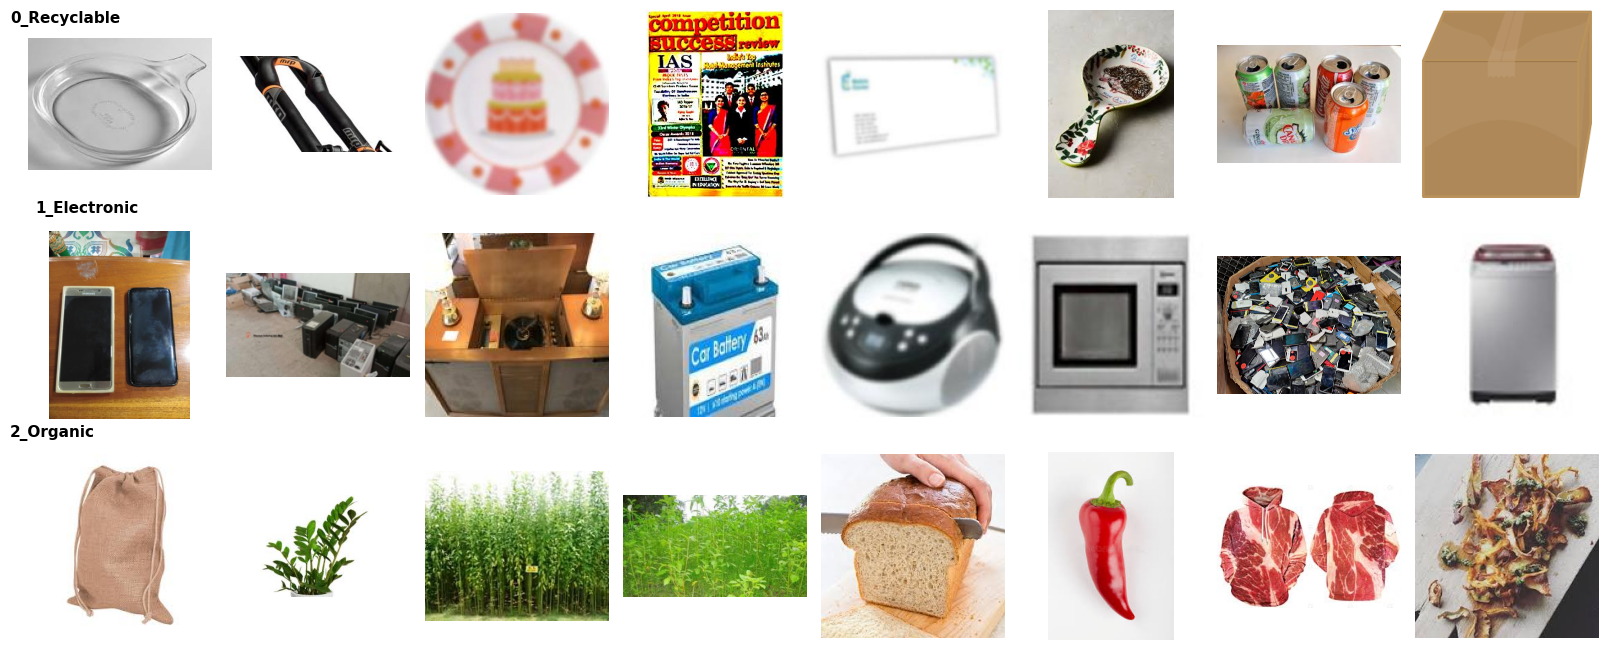

In [51]:
import matplotlib.pyplot as plt

def show_sample_grid(sampled_files, class_folders, n_per_class=8):
    """Tampilkan grid sample gambar acak per kelas untuk cek visual background/objek."""
    fig, axes = plt.subplots(len(class_folders), n_per_class, figsize=(n_per_class * 2, len(class_folders) * 2.2))

    for row, cls in enumerate(class_folders):
        # ambil subset kecil dari sample yang sudah ada (reuse sampled_files dari step warna)
        files_to_show = random.sample(sampled_files[cls], n_per_class)
        for col, f in enumerate(files_to_show):
            img = Image.open(f).convert("RGB")
            ax = axes[row, col]
            ax.imshow(img)
            ax.axis("off")
            if col == 0:
                ax.set_ylabel(cls, fontsize=10)
        axes[row, 0].set_title(cls, loc="left", fontsize=11, fontweight="bold", x=-0.1, y=1.05)

    plt.tight_layout()
    plt.show()

show_sample_grid(sampled_files, class_folders, n_per_class=8)

Statistik background variance per kelas:
              count         mean          std  min         25%          50%  \
class                                                                         
0_Recyclable  500.0  1361.773418  2099.891098  0.0    0.545666   305.331473   
1_Electronic  500.0  1651.417410  2031.391552  0.0  217.776224   853.073394   
2_Organic     500.0  1997.839960  2066.857523  0.0  268.098360  1524.383777   

                      75%           max  
class                                    
0_Recyclable  2004.664929  14525.814145  
1_Electronic  2211.642600  11285.790141  
2_Organic     2895.608917  11242.286189  

Proporsi gambar dengan background polos (variance < threshold) per kelas:
class
0_Recyclable    0.388
1_Electronic    0.152
2_Organic       0.170
Name: is_plain_bg, dtype: float64


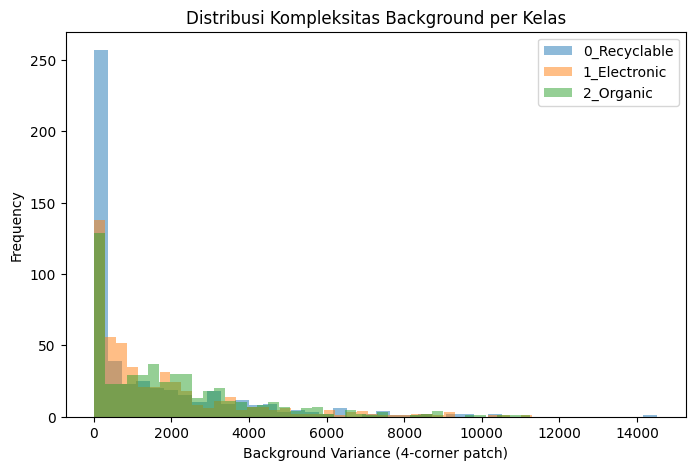

In [52]:
import numpy as np

def compute_background_complexity(img, patch_size=30):
    """
    Ambil 4 patch di pojok gambar (kemungkinan besar area background),
    hitung rata-rata variance pixel sebagai proxy 'kompleksitas background'.
    Variance rendah -> background polos/seragam (studio putih)
    Variance tinggi -> background kompleks/natural
    """
    arr = np.array(img)
    h, w, _ = arr.shape
    p = patch_size

    # 4 pojok: top-left, top-right, bottom-left, bottom-right
    corners = [
        arr[0:p, 0:p],
        arr[0:p, w-p:w],
        arr[h-p:h, 0:p],
        arr[h-p:h, w-p:w]
    ]

    variances = [c.var() for c in corners]
    return np.mean(variances)

# --- Hitung untuk semua sample yang sudah ada (reuse sampled_files) ---
bg_results = []

for cls, files in sampled_files.items():
    for f in files:
        try:
            img = Image.open(f).convert("RGB")
            bg_var = compute_background_complexity(img)
            bg_results.append({"class": cls, "file": str(f), "bg_variance": bg_var})
        except Exception as e:
            pass  # sudah dicek corrupt di step sebelumnya, skip kalau ada error edge-case

df_bg = pd.DataFrame(bg_results)

# --- Ringkasan statistik per kelas ---
print("Statistik background variance per kelas:")
print(df_bg.groupby("class")["bg_variance"].describe())

# --- Threshold sederhana: anggap 'polos' kalau variance di bawah nilai tertentu ---
# Threshold ini masih kasar, akan kita kalibrasi setelah lihat distribusinya
threshold = 50  # placeholder, sesuaikan setelah lihat output describe() di atas

df_bg["is_plain_bg"] = df_bg["bg_variance"] < threshold
print("\nProporsi gambar dengan background polos (variance < threshold) per kelas:")
print(df_bg.groupby("class")["is_plain_bg"].mean())

# --- Visualisasi distribusi ---
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
for cls in class_folders:
    subset = df_bg[df_bg["class"] == cls]["bg_variance"]
    ax.hist(subset, bins=40, alpha=0.5, label=cls)
ax.set_xlabel("Background Variance (4-corner patch)")
ax.set_ylabel("Frequency")
ax.set_title("Distribusi Kompleksitas Background per Kelas")
ax.legend()
plt.show()

In [53]:

dim_results = []

for cls, files in sampled_files.items():
    for f in files:
        try:
            with Image.open(f) as img:
                w, h = img.size
                dim_results.append({
                    "class": cls,
                    "file": str(f),
                    "width": w,
                    "height": h,
                    "aspect_ratio": round(w / h, 3),
                    "orientation": "square" if abs(w - h) <= 5 else ("landscape" if w > h else "portrait")
                })
        except Exception as e:
            pass  # sudah dicek corrupt sebelumnya

df_dim = pd.DataFrame(dim_results)

print("=== Statistik Width & Height per Kelas ===")
print(df_dim.groupby("class")[["width", "height"]].describe())

print("\n=== Statistik Aspect Ratio per Kelas ===")
print(df_dim.groupby("class")["aspect_ratio"].describe())

print("\n=== Distribusi Orientasi per Kelas (proporsi) ===")
print(pd.crosstab(df_dim["class"], df_dim["orientation"], normalize="index").round(3))

=== Statistik Width & Height per Kelas ===
              width                                                            \
              count     mean         std    min     25%    50%    75%     max   
class                                                                           
0_Recyclable  500.0  240.034   44.883068   72.0  222.25  225.0  275.0   458.0   
1_Electronic  500.0  565.278  970.932820  150.0  150.00  150.0  640.0  8000.0   
2_Organic     500.0  262.320   41.178112  150.0  225.00  267.0  285.0   448.0   

             height                                                           
              count     mean         std    min    25%    50%    75%     max  
class                                                                         
0_Recyclable  500.0  212.232   33.965534  110.0  183.0  221.0  225.0   302.0  
1_Electronic  500.0  487.008  809.805741  150.0  150.0  150.0  482.0  6000.0  
2_Organic     500.0  195.648   31.191311  112.0  176.0  186.0  224.0   313.

In [54]:

electronic_dims = df_dim[df_dim["class"] == "1_Electronic"].copy()

# Anggap "kecil seragam" kalau width DAN height persis 150 (atau sangat dekat)
electronic_dims["is_small_150"] = (electronic_dims["width"] == 150) & (electronic_dims["height"] == 150)
# Cell: Cek proporsi sub-populasi dimensi di kelas Electronic
n_small = electronic_dims["is_small_150"].sum()
n_total = len(electronic_dims)
print(f"Jumlah gambar Electronic dengan ukuran persis 150x150: {n_small} / {n_total} ({n_small/n_total:.1%})")

# Lihat sebaran ukuran untuk sisanya (non-150x150) -> apakah memang melonjak jauh atau ada gradasi?
print("\nStatistik width untuk gambar Electronic yang BUKAN 150x150:")
print(electronic_dims[~electronic_dims["is_small_150"]]["width"].describe())

# Ambil beberapa contoh file dari masing-masing kelompok untuk dicek visual manual
small_samples = electronic_dims[electronic_dims["is_small_150"]]["file"].head(5).tolist()
large_samples = electronic_dims[~electronic_dims["is_small_150"]].sort_values("width", ascending=False)["file"].head(5).tolist()

print("\nContoh file 'kecil seragam' (150x150):")
for f in small_samples:
    print(f)

print("\nContoh file 'besar' (bukan 150x150):")
for f in large_samples:
    print(f)

Jumlah gambar Electronic dengan ukuran persis 150x150: 344 / 500 (68.8%)

Statistik width untuk gambar Electronic yang BUKAN 150x150:
count     156.000000
mean     1481.019231
std      1344.688396
min       249.000000
25%       680.750000
50%      1028.000000
75%      1300.000000
max      8000.000000
Name: width, dtype: float64

Contoh file 'kecil seragam' (150x150):
c:\Users\HP\Documents\BDC 2026\satria-data-bdc-2026-1\train\1_Electronic\Washing_Machine_1.jpg
c:\Users\HP\Documents\BDC 2026\satria-data-bdc-2026-1\train\1_Electronic\pcb_141.jpg
c:\Users\HP\Documents\BDC 2026\satria-data-bdc-2026-1\train\1_Electronic\Mouse_181.jpg
c:\Users\HP\Documents\BDC 2026\satria-data-bdc-2026-1\train\1_Electronic\Player_251.jpg
c:\Users\HP\Documents\BDC 2026\satria-data-bdc-2026-1\train\1_Electronic\Player_170.jpg

Contoh file 'besar' (bukan 150x150):
c:\Users\HP\Documents\BDC 2026\satria-data-bdc-2026-1\train\1_Electronic\Copy of IMG_20200328_214915.jpg
c:\Users\HP\Documents\BDC 2026\satria-data-b

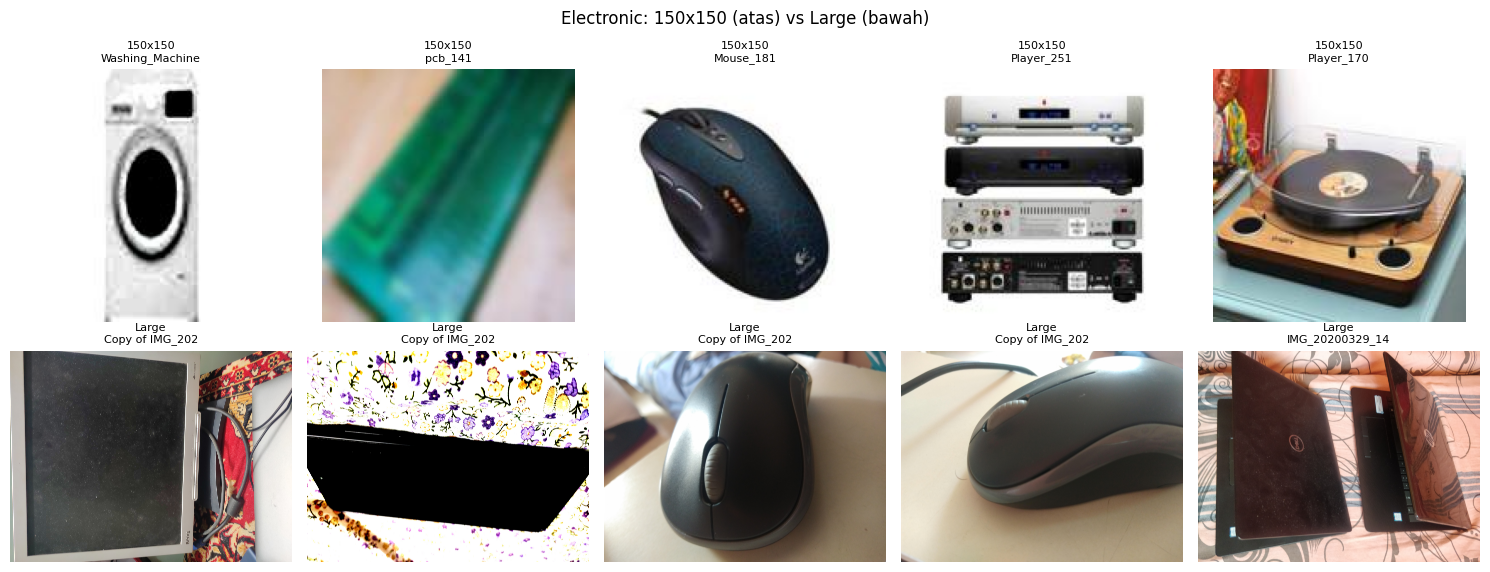

In [55]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, f in enumerate(small_samples):
    img = Image.open(f)
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"150x150\n{Path(f).stem[:15]}", fontsize=8)
    axes[0, i].axis("off")

for i, f in enumerate(large_samples):
    img = Image.open(f)
    axes[1, i].imshow(img)
    axes[1, i].set_title(f"Large\n{Path(f).stem[:15]}", fontsize=8)
    axes[1, i].axis("off")

plt.suptitle("Electronic: 150x150 (atas) vs Large (bawah)")
plt.tight_layout()
plt.show()

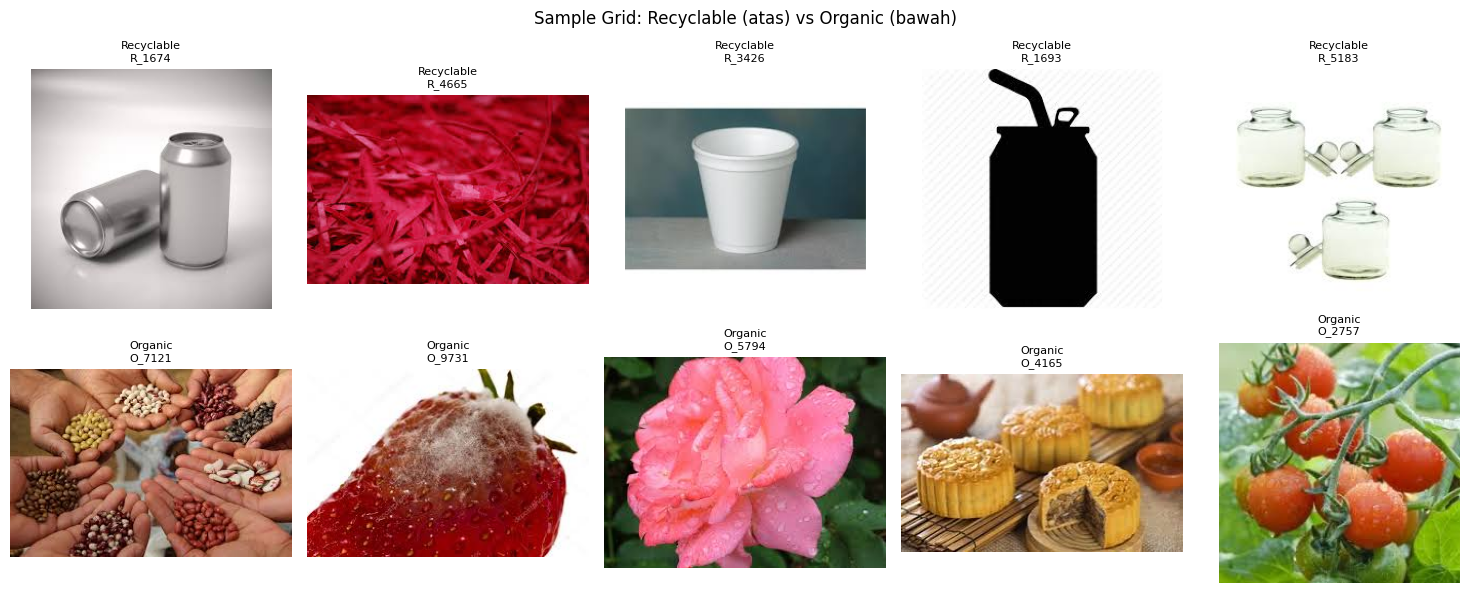

In [56]:
import random

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

recyclable_samples = random.sample(sampled_files["0_Recyclable"], 5)
organic_samples = random.sample(sampled_files["2_Organic"], 5)

for i, f in enumerate(recyclable_samples):
    img = Image.open(f)
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Recyclable\n{Path(f).stem[:15]}", fontsize=8)
    axes[0, i].axis("off")

for i, f in enumerate(organic_samples):
    img = Image.open(f)
    axes[1, i].imshow(img)
    axes[1, i].set_title(f"Organic\n{Path(f).stem[:15]}", fontsize=8)
    axes[1, i].axis("off")

plt.suptitle("Sample Grid: Recyclable (atas) vs Organic (bawah)")
plt.tight_layout()
plt.show()

=== Statistik Brightness per Kelas ===
              count        mean        std        min         25%         50%  \
class                                                                           
0_Recyclable  500.0  181.762547  48.895984  14.148217  151.089792  188.408240   
1_Electronic  500.0  142.347171  46.311070  25.651511  107.983152  135.126319   
2_Organic     500.0  145.049034  46.819262   5.246384  107.984744  138.237138   

                     75%         max  
class                                 
0_Recyclable  222.024372  254.093867  
1_Electronic  179.160233  243.170533  
2_Organic     186.668740  249.561066  

=== Rata-rata Channel Warna (R/G/B) per Kelas ===
                  r_mean      g_mean      b_mean
class                                           
0_Recyclable  187.221521  181.610683  176.455437
1_Electronic  144.822147  142.951888  139.267478
2_Organic     167.013816  149.931305  118.201981


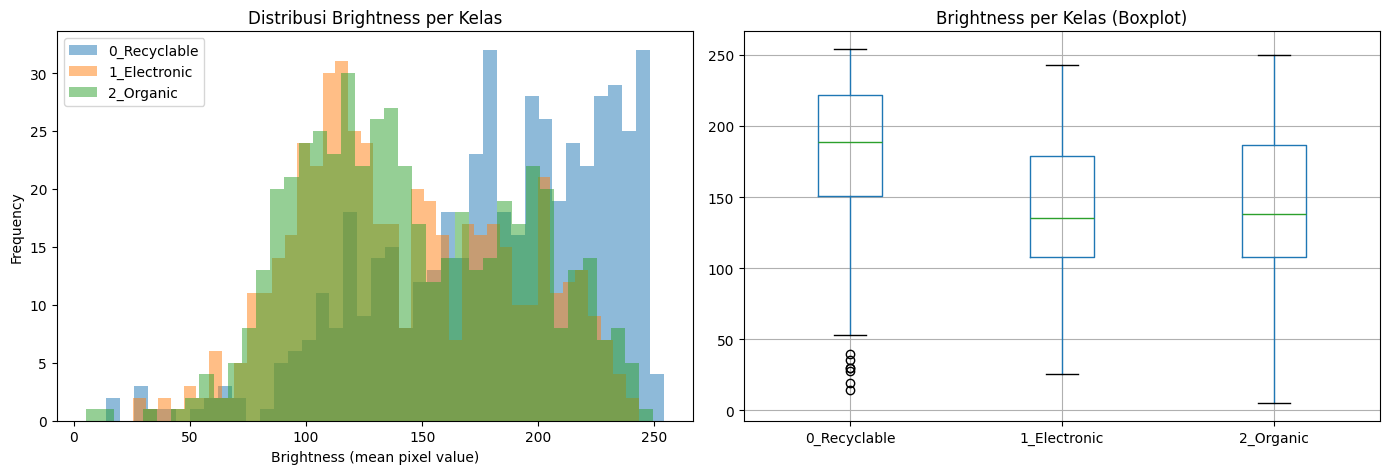

In [57]:
import numpy as np

brightness_results = []

for cls, files in sampled_files.items():
    for f in files:
        try:
            with Image.open(f) as img:
                img_rgb = img.convert("RGB")
                arr = np.array(img_rgb)
                
                # Brightness = rata-rata semua channel (perceived luminance approx)
                brightness = arr.mean()
                
                # Rata-rata per channel (R, G, B)
                r_mean, g_mean, b_mean = arr[:,:,0].mean(), arr[:,:,1].mean(), arr[:,:,2].mean()
                
                brightness_results.append({
                    "class": cls,
                    "file": str(f),
                    "brightness": brightness,
                    "r_mean": r_mean,
                    "g_mean": g_mean,
                    "b_mean": b_mean
                })
        except Exception as e:
            pass

df_brightness = pd.DataFrame(brightness_results)

print("=== Statistik Brightness per Kelas ===")
print(df_brightness.groupby("class")["brightness"].describe())

print("\n=== Rata-rata Channel Warna (R/G/B) per Kelas ===")
print(df_brightness.groupby("class")[["r_mean", "g_mean", "b_mean"]].mean())

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cls in class_folders:
    subset = df_brightness[df_brightness["class"] == cls]["brightness"]
    axes[0].hist(subset, bins=40, alpha=0.5, label=cls)
axes[0].set_xlabel("Brightness (mean pixel value)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribusi Brightness per Kelas")
axes[0].legend()

df_brightness.boxplot(column="brightness", by="class", ax=axes[1])
axes[1].set_title("Brightness per Kelas (Boxplot)")
axes[1].set_xlabel("")
plt.suptitle("")
plt.tight_layout()
plt.show()

=== Statistik Foreground Ratio (proxy ukuran objek) per Kelas ===
              count      mean       std       min       25%       50%  \
class                                                                   
0_Recyclable  500.0  0.589086  0.297655  0.014756  0.322026  0.575644   
1_Electronic  500.0  0.718272  0.225279  0.103778  0.541889  0.776323   
2_Organic     500.0  0.760695  0.247048  0.071475  0.586920  0.870786   

                   75%       max  
class                             
0_Recyclable  0.885485  0.999782  
1_Electronic  0.915333  0.999467  
2_Organic     0.952097  1.000000  


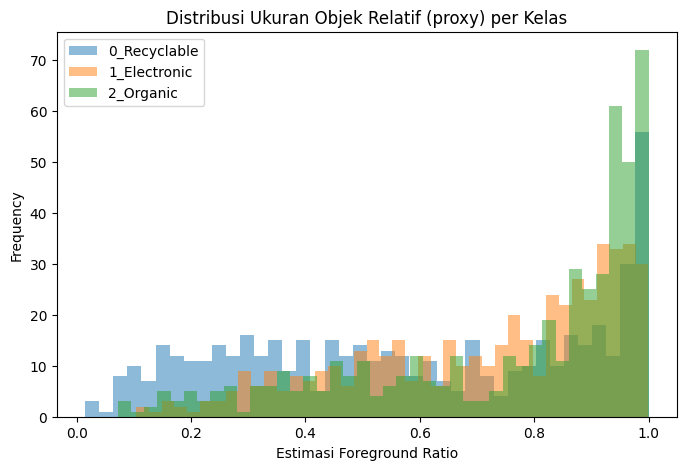

In [58]:
def estimate_foreground_ratio(img_path, threshold=30):
    with Image.open(img_path) as img:
        img_rgb = img.convert("RGB")
        arr = np.array(img_rgb).astype(int)
        h, w = arr.shape[:2]
        
        # Ambil warna referensi background dari rata-rata 4 pojok (patch kecil)
        patch = 15
        corners = np.concatenate([
            arr[:patch, :patch].reshape(-1, 3),
            arr[:patch, -patch:].reshape(-1, 3),
            arr[-patch:, :patch].reshape(-1, 3),
            arr[-patch:, -patch:].reshape(-1, 3)
        ])
        bg_color = corners.mean(axis=0)
        
        # Hitung selisih tiap pixel dari warna background
        diff = np.sqrt(((arr - bg_color) ** 2).sum(axis=2))
        foreground_mask = diff > threshold
        
        foreground_ratio = foreground_mask.mean()
        return foreground_ratio

fg_results = []
for cls, files in sampled_files.items():
    for f in files:
        try:
            ratio = estimate_foreground_ratio(f)
            fg_results.append({"class": cls, "file": str(f), "foreground_ratio": ratio})
        except Exception as e:
            pass

df_fg = pd.DataFrame(fg_results)

print("=== Statistik Foreground Ratio (proxy ukuran objek) per Kelas ===")
print(df_fg.groupby("class")["foreground_ratio"].describe())

fig, ax = plt.subplots(figsize=(8, 5))
for cls in class_folders:
    subset = df_fg[df_fg["class"] == cls]["foreground_ratio"]
    ax.hist(subset, bins=40, alpha=0.5, label=cls)
ax.set_xlabel("Estimasi Foreground Ratio")
ax.set_ylabel("Frequency")
ax.set_title("Distribusi Ukuran Objek Relatif (proxy) per Kelas")
ax.legend()
plt.show()

In [59]:
import hashlib
from pathlib import Path
from collections import defaultdict

def compute_md5(file_path):
    hasher = hashlib.md5()
    with open(file_path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            hasher.update(chunk)
    return hasher.hexdigest()

# Kumpulkan SEMUA file train (bukan sample) beserta hash-nya
train_dir = data_dir / "train"
hash_to_files = defaultdict(list)

all_train_files = []
for cls_dir in sorted(train_dir.iterdir()):
    if not cls_dir.is_dir():
        continue
    for f in cls_dir.glob("*.*"):
        all_train_files.append((cls_dir.name, f))

print(f"Total file train yang akan di-hash: {len(all_train_files)}")

for cls_name, f in all_train_files:
    try:
        h = compute_md5(f)
        hash_to_files[h].append((cls_name, f))
    except Exception as e:
        print(f"Gagal hash: {f} -> {e}")

# Filter: hash yang punya lebih dari 1 file (berarti duplikat)
duplicate_groups = {h: files for h, files in hash_to_files.items() if len(files) > 1}

print(f"\nJumlah grup duplikat (exact-hash match) dalam train: {len(duplicate_groups)}")

# Pisahkan: duplikat CROSS-CLASS vs WITHIN-CLASS
cross_class_dupes = {}
within_class_dupes = {}

for h, files in duplicate_groups.items():
    classes_involved = set(cls for cls, f in files)
    if len(classes_involved) > 1:
        cross_class_dupes[h] = files
    else:
        within_class_dupes[h] = files

print(f"\n🚩 Duplikat CROSS-CLASS (file sama, label beda): {len(cross_class_dupes)} grup")
print(f"Duplikat WITHIN-CLASS (file sama, label sama): {len(within_class_dupes)} grup")

# Tampilkan detail cross-class dulu (prioritas)
if cross_class_dupes:
    print("\n=== DETAIL DUPLIKAT CROSS-CLASS ===")
    for h, files in list(cross_class_dupes.items())[:10]:  # tampilkan max 10 dulu
        print(f"\nHash: {h}")
        for cls, f in files:
            print(f"  [{cls}] {f.name}")

# Hitung total file yang terlibat duplikat within-class per kelas
within_class_count = defaultdict(int)
for h, files in within_class_dupes.items():
    cls = files[0][0]
    within_class_count[cls] += len(files)

print("\n=== Jumlah file terlibat duplikat WITHIN-CLASS per kelas ===")
for cls, count in within_class_count.items():
    print(f"{cls}: {count} file")

Total file train yang akan di-hash: 26527

Jumlah grup duplikat (exact-hash match) dalam train: 62

🚩 Duplikat CROSS-CLASS (file sama, label beda): 1 grup
Duplikat WITHIN-CLASS (file sama, label sama): 61 grup

=== DETAIL DUPLIKAT CROSS-CLASS ===

Hash: 95bd2693fd68b87d40601c3002ebdf21
  [0_Recyclable] R_799.jpg
  [2_Organic] O_8873.jpg

=== Jumlah file terlibat duplikat WITHIN-CLASS per kelas ===
0_Recyclable: 18 file
1_Electronic: 60 file
2_Organic: 44 file


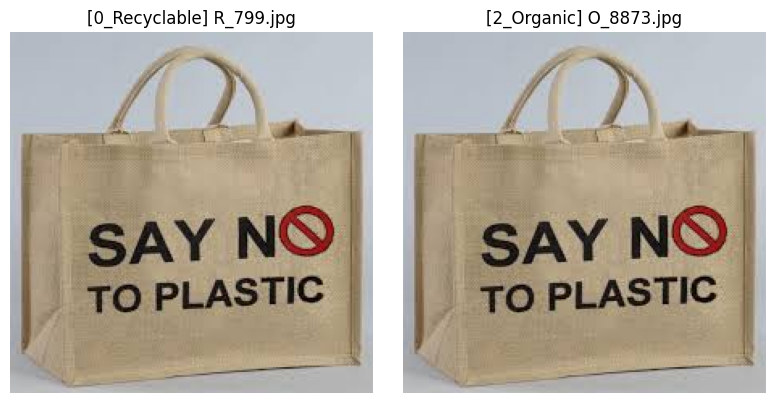

5 grup duplikat within-class terbesar:

Jumlah copy: 2
  [2_Organic] O_10162.jpg
  [2_Organic] O_6766.jpg

Jumlah copy: 2
  [1_Electronic] 630(1).jpeg
  [1_Electronic] 630.jpeg

Jumlah copy: 2
  [0_Recyclable] R_8442.jpg
  [0_Recyclable] R_9284.jpg

Jumlah copy: 2
  [2_Organic] O_2061.jpg
  [2_Organic] O_6618.jpg

Jumlah copy: 2
  [2_Organic] O_9640(1).jpg
  [2_Organic] O_9640.jpg


In [60]:
# 1. Visual check duplikat cross-class (prioritas tertinggi)
import matplotlib.pyplot as plt

cross_pair = list(cross_class_dupes.values())[0]
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for i, (cls, f) in enumerate(cross_pair):
    img = Image.open(f)
    axes[i].imshow(img)
    axes[i].set_title(f"[{cls}] {f.name}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

# 2. Ukuran grup duplikat within-class terbesar (cek apakah ada 1 file yang di-copy berkali-kali)
group_sizes = sorted([(len(files), h) for h, files in within_class_dupes.items()], reverse=True)
print("5 grup duplikat within-class terbesar:")
for size, h in group_sizes[:5]:
    files = within_class_dupes[h]
    print(f"\nJumlah copy: {size}")
    for cls, f in files:
        print(f"  [{cls}] {f.name}")